**Load and Inspect**

 Tip: At least one column will not be the type you expect. Don't fix anything yet — eda.ipynb is for finding problems, preprocessing.ipynb is for fixing them.

In [1]:
import pandas as pandy
import numpy as numpy
import matplotlib.pyplot as mplot


In [6]:
ridership_df = pandy.read_csv('../Data/citibike_weather_daily.csv')
ridership_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1610 entries, 0 to 1609
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   ride_date         1610 non-null   str    
 1   num_rides         1610 non-null   int64  
 2   avg_duration_min  1610 non-null   float64
 3   temp_f            1610 non-null   float64
 4   max_temp_f        1610 non-null   float64
 5   min_temp_f        1610 non-null   float64
 6   wind_speed_knots  1610 non-null   float64
 7   precip_in         1610 non-null   float64
 8   day_of_week       1610 non-null   str    
 9   month             1610 non-null   int64  
dtypes: float64(6), int64(2), str(2)
memory usage: 125.9 KB


In [9]:
ridership_df.head()

,ride_date,num_rides,avg_duration_min,temp_f,max_temp_f,min_temp_f,wind_speed_knots,precip_in,day_of_week,month
0,2013-07-01,16650,16.31,74.8,78.1,73.4,7.8,0.00,Monday,7
1,2013-07-02,22745,15.97,76.1,82.9,73.0,8.0,0.73,Tuesday,7
2,2013-07-03,21864,16.24,78.5,84.9,73.9,8.8,0.06,Wednesday,7
3,2013-07-04,22326,21.22,82.0,91.0,73.9,8.6,0.96,Thursday,7
4,2013-07-05,21842,18.04,84.4,93.0,75.9,9.0,0.00,Friday,7


In [10]:
ridership_df.shape

(1610, 10)

In [15]:
ridership_df.dtypes

ride_date           datetime64[us]
num_rides                    int64
avg_duration_min           float64
temp_f                     float64
max_temp_f                 float64
min_temp_f                 float64
wind_speed_knots           float64
precip_in                  float64
day_of_week                    str
month                        int64
dtype: object

In [14]:
ridership_df.describe

<bound method NDFrame.describe of       ride_date  num_rides  avg_duration_min  temp_f  max_temp_f  min_temp_f  \
0    2013-07-01      16650             16.31    74.8        78.1        73.4   
1    2013-07-02      22745             15.97    76.1        82.9        73.0   
2    2013-07-03      21864             16.24    78.5        84.9        73.9   
3    2013-07-04      22326             21.22    82.0        91.0        73.9   
4    2013-07-05      21842             18.04    84.4        93.0        75.9   
...         ...        ...               ...     ...         ...         ...   
1605 2018-05-27      25814             24.00    68.8        91.9        59.0   
1606 2018-05-28      49043             22.91    60.2        82.0        55.9   
1607 2018-05-29      69090             17.07    72.8        87.1        55.9   
1608 2018-05-30      72321             16.62    69.0        87.1        63.0   
1609 2018-05-31      55794             13.87    64.0        77.0        60.1   

     

Observations:

CSV loaded as expected. Data types match up with Data Dictionary. Ride_date seems to be loaded initally as a string, but will be formatted properly later on in Preprocessing. 

**Profile the Distributions**

 Tip: Government datasets often encode missing values as numbers rather than leaving cells blank. NOAA's GSOD documentation says missing observations are coded as 9999.9 (temperatures), 999.9 (wind), or 99.99 (precipitation). A careful analyst checks whether any of those codes made it into their slice of the data.

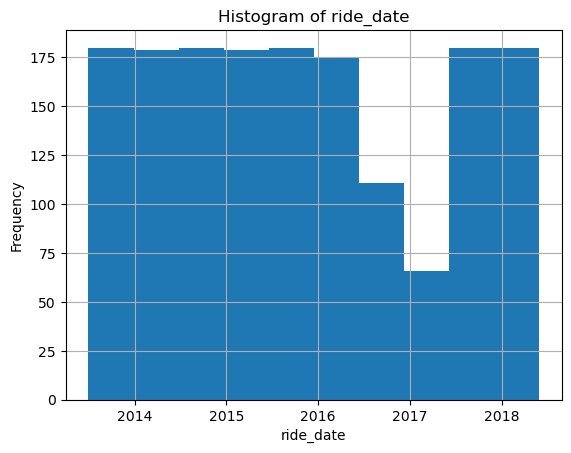

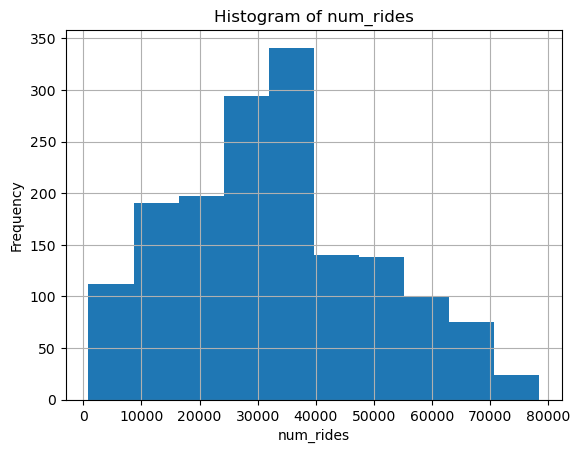

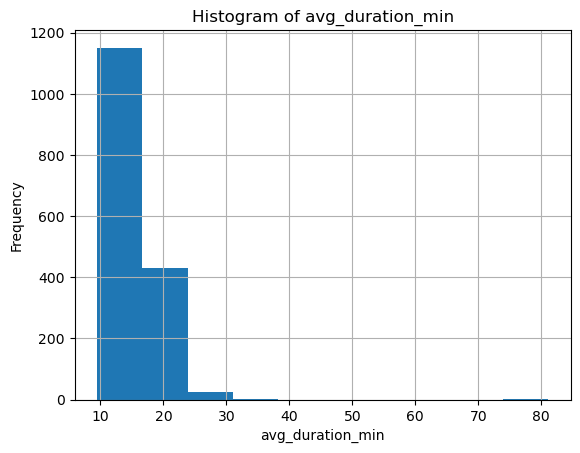

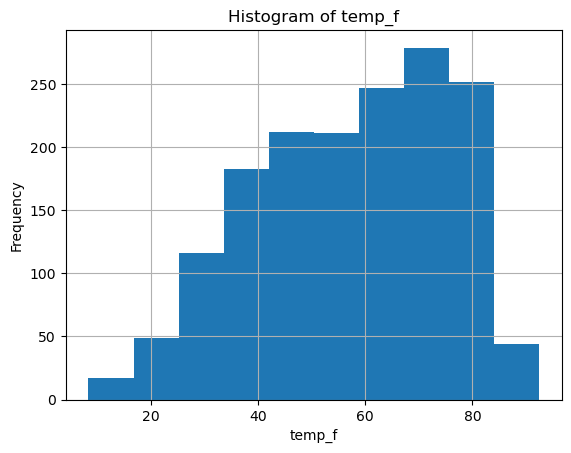

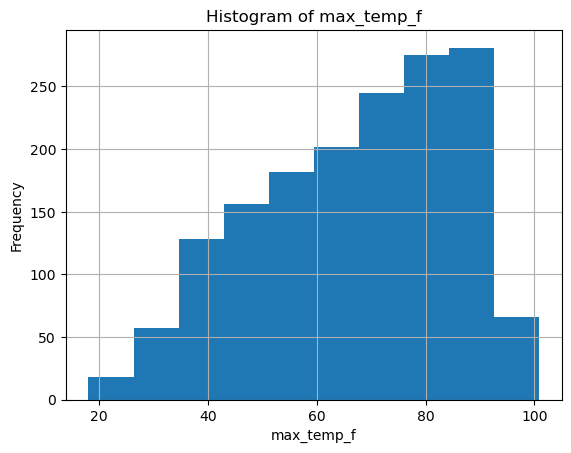

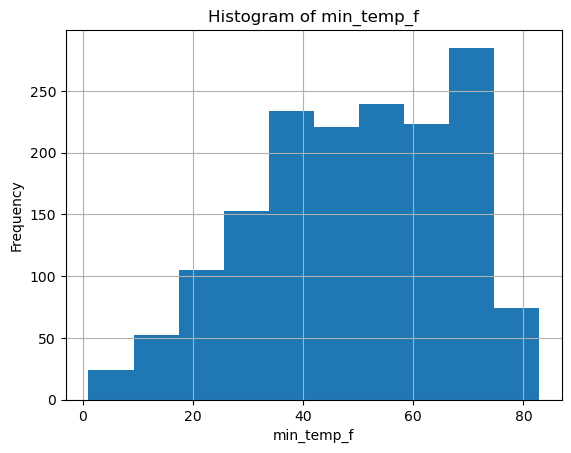

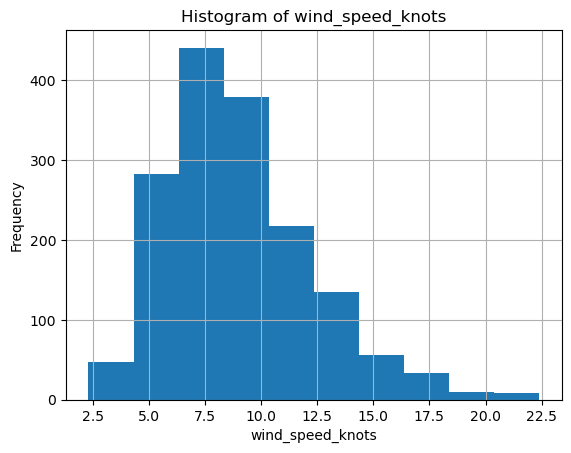

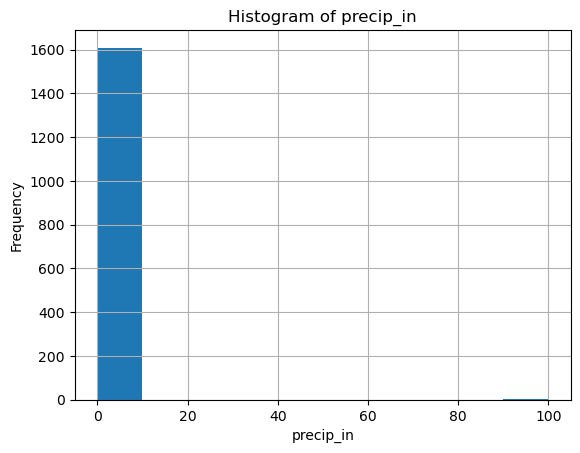

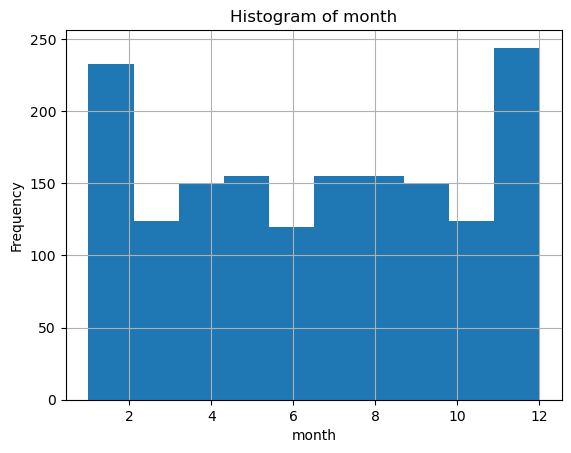

In [16]:
for c in ridership_df:
    if c in ridership_df.describe():
        mplot.figure()
        ridership_df[c].hist()
        mplot.title(f"Histogram of {c}")
        mplot.xlabel(c)
        mplot.ylabel("Frequency")

**Relationships with the Target**

 Tip: Look closely at the very hottest days. Does ridership keep climbing forever as it gets hotter, or does something else happen? Remember this when you get to feature engineering.


In [17]:
weather_columns = ridership_df.loc[:,['temp_f','max_temp_f','min_temp_f','wind_speed_knots','precip_in']]
weather_columns.info()

<class 'pandas.DataFrame'>
RangeIndex: 1610 entries, 0 to 1609
Data columns (total 5 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   temp_f            1610 non-null   float64
 1   max_temp_f        1610 non-null   float64
 2   min_temp_f        1610 non-null   float64
 3   wind_speed_knots  1610 non-null   float64
 4   precip_in         1610 non-null   float64
dtypes: float64(5)
memory usage: 63.0 KB


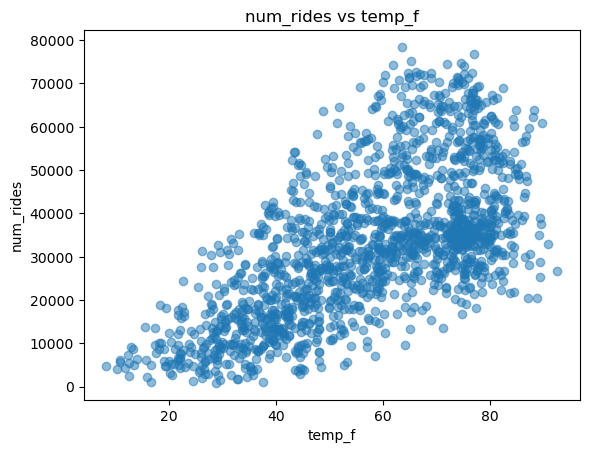

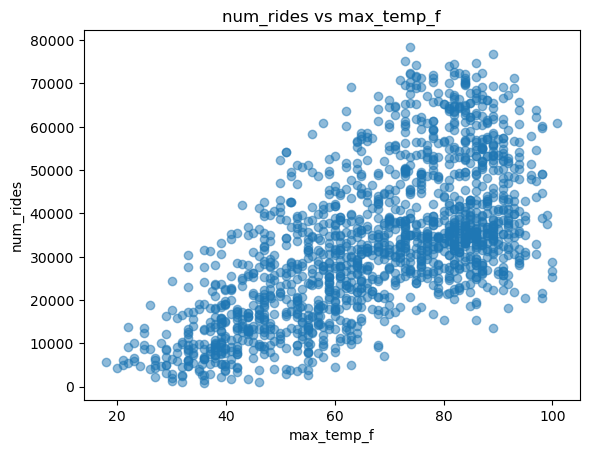

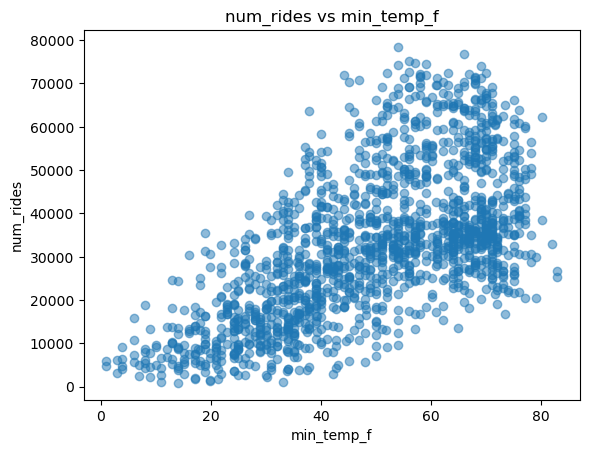

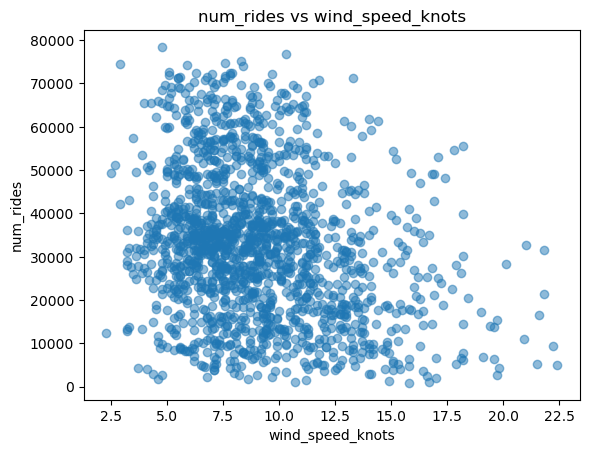

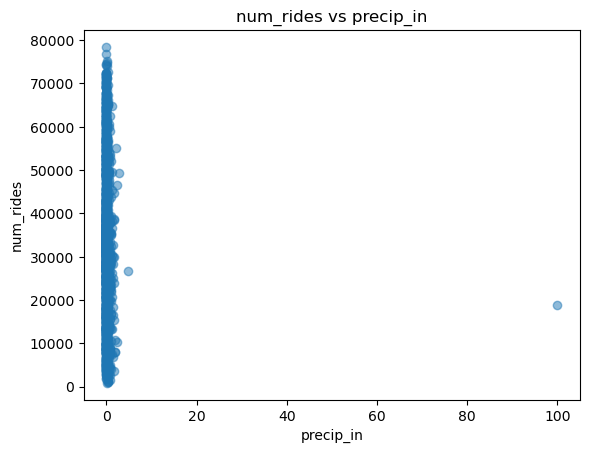

In [21]:
for c in weather_columns:
    mplot.scatter(ridership_df[c], ridership_df['num_rides'], alpha=0.5)
    
    # Format the labels and title dynamically
    mplot.xlabel(c)
    mplot.ylabel('num_rides')
    mplot.title(f'{'num_rides'} vs {c}')
    mplot.show()

Observations: 

Everything looks strong so far except the last scatterplot. There seems to be an upward trend across the temp plots, that peters off at around 80 degrees across all 3 temp plots, and then slightly trends downward. There is a slight, weaker downward trend for the num_rides vs wind knots. The data is not well distributed in num_rides vs precip_in, perhaps because of an outlier or missing value? There is 1 point in 100 which seems to be effecting everything.

**Ridership Over Time**

 Tip: The bike share system itself changed over these six years: more stations, more bikes, more members. Your model needs some way to know what year it is.

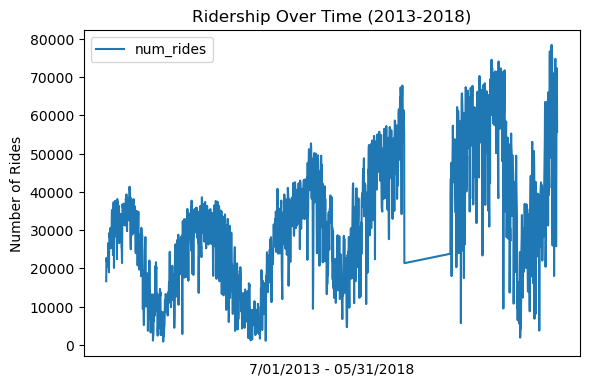

In [33]:
ridership_df.plot(x='ride_date', y='num_rides', kind='line')
mplot.xlabel('7/01/2013 - 05/31/2018')
mplot.ylabel('Number of Rides')
mplot.title('Ridership Over Time (2013-2018)')
mplot.xticks([])
mplot.show()

In [34]:
ride_dates = pandy.to_datetime(ridership_df['ride_date']) 

july_ridership = ridership_df[ride_dates.dt.month == 7].copy()
july_ridership['year'] = ride_dates[ride_dates.dt.month == 7].dt.year.values
july_avg = july_ridership.groupby('year')['num_rides'].mean()

july_avg

year
2013    27206.967742
2014    31252.967742
2015    35021.806452
2016    44519.677419
2017    55987.064516
Name: num_rides, dtype: float64

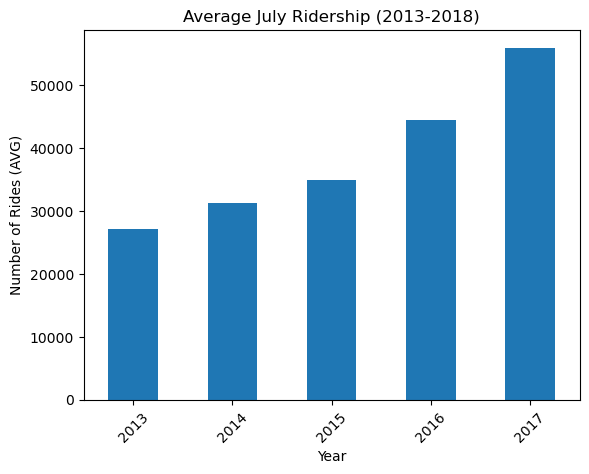

In [39]:
july_avg.plot(kind='bar')

mplot.xlabel('Year')
mplot.ylabel('Number of Rides (AVG)')
mplot.title('Average July Ridership (2013-2018)')
mplot.xticks(rotation=45)

mplot.show()

*Observations*

Both visualizations show an increase in ridership over time. Overall in the initial line graph, and on average in the bar chart as well. Using July as an example, the average number of rides almost doubled from 2013 to 2017(approx 30k to 60k). If a prediction model were only to account for weather and weekday, it would possibly not take these yearly observations into account. A more accurate model would find a way to include time as a feature.

**The Weekly Rhythm**

Compare average ridership across days of the week. What stands out?

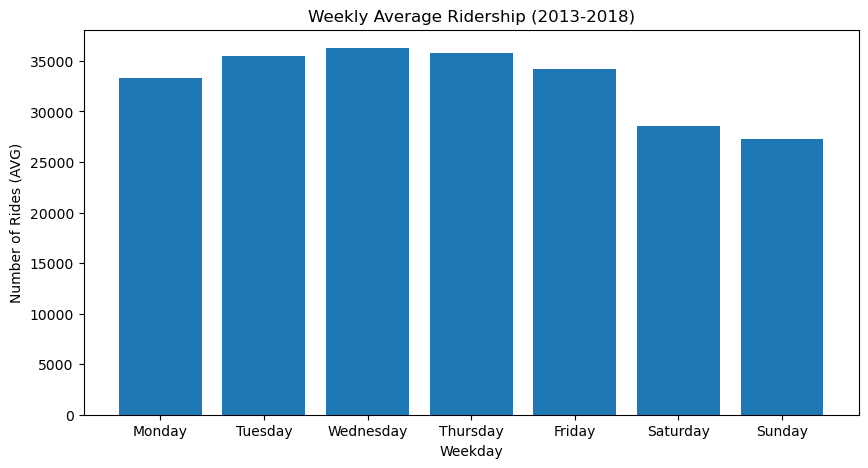

In [44]:
weekly_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
avg_rides = ridership_df.groupby('day_of_week')['num_rides'].mean().reindex(weekly_order)

mplot.figure(figsize=(10, 5))
mplot.bar(avg_rides.index, avg_rides.values)
mplot.xlabel('Weekday')
mplot.ylabel('Number of Rides (AVG)')
mplot.title('Weekly Average Ridership (2013-2018)')
mplot.show()

*Observations*

Taking the recurring pattern of weekdays, there is a cyclical or curving data trend here. Wednesday is the peak day of avg ridership. Ridership slows down from Thursdays onward, until Monday hits and ridership builds up to hitting midweek peaks once more. This is interesting data on ridership. One could assume that perhaps mostly commuters use citibike for work, and less riders use it for leisure on weekends. But in a city like NYC, commuters work hard every single day of the week. Average weekly ridership might be shaped by commuters over leisure users, but perhaps it depends on the type of commuter who would prefer to bike ride over any other source of commuting (IE: trains, bus, or car). 

**The Missing Days**

 Tip: pd.date_range() gives you every date in a span; compare it against the dates you actually have.



In [45]:
date_range = pandy.date_range(start = "07/01/2013", end = "05/31/2018")
print(date_range)

DatetimeIndex(['2013-07-01', '2013-07-02', '2013-07-03', '2013-07-04',
               '2013-07-05', '2013-07-06', '2013-07-07', '2013-07-08',
               '2013-07-09', '2013-07-10',
               ...
               '2018-05-22', '2018-05-23', '2018-05-24', '2018-05-25',
               '2018-05-26', '2018-05-27', '2018-05-28', '2018-05-29',
               '2018-05-30', '2018-05-31'],
              dtype='datetime64[us]', length=1796, freq='D')


*Observations*

While our dataset contains 1,610 rows, date range shows a length of 1,796. 1796 - 1,610 = 186, which means there are 186 dates missing from the dataset. Unfortunately I do not know how to find where these dates could be missing from, but my best hypothesis would be perhaps national holidays and inclimate weather. There are days that most national businesses observe and close their business, and bad weather like snow storms or flooding could lead to dates being closed as well. 